# **Mental Health in Tech Survey - EDA**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** <Your Name>

# **Project Summary -**

This project explores the 2014 Open Sourcing Mental Illness (OSMI) survey of 1,259 tech-industry employees, which captures attitudes toward mental health and the frequency of mental health conditions in the workplace. The dataset spans 27 fields covering demographics (age, gender, country), employer characteristics (company size, remote work, whether the employer is a tech company), and a series of Yes/No/Don't-know questions on benefits, care options, wellness programs, anonymity protections, leave policies, and perceived consequences of disclosing a mental health issue.

The raw data required meaningful cleaning before analysis: `Age` contained clearly invalid entries (from -1726 to 99,999,999,999), and `Gender` was entered as free text, producing 49 distinct spellings for what are effectively 2-3 categories. Both were standardized. Missing values in `state` (515), `self_employed` (18), and `work_interfere` (264) were each handled according to why they were likely missing rather than with a single blanket rule - for example, `work_interfere` is largely missing because those respondents have not sought treatment, so it is filled with "Not applicable" rather than the column mode.

After cleaning, the EDA proceeds through univariate analysis (age, gender, treatment-seeking rates, country mix, company size), then bivariate analysis pairing `treatment` and other outcome variables against employer-side factors like `benefits`, `care_options`, `wellness_program`, `anonymity`, and `leave` policy. A correlation heatmap and pair plot close out the visual analysis by looking at how several encoded Yes/No variables move together.

The central finding is that employer-side transparency and support - clearly communicated benefits, known care options, and protected anonymity - track closely with whether an employee has sought treatment and whether they fear negative consequences from disclosure. This points to a concrete, actionable business objective: mental health *benefits* existing on paper matter far less than employees actually *knowing about and trusting* those benefits. The Solution to Business Objective section translates this into a small set of concrete recommendations for tech employers, and the Conclusion summarizes the overall picture the data tells.

# **GitHub Link -**

_Add your own GitHub repository link here once you've pushed this project._

# **Problem Statement**


Mental health remains a significantly under-addressed issue in tech workplaces relative to physical health, despite the high-pressure, high-stress nature of the industry. Employers often don't know whether their existing mental health policies (benefits, wellness programs, leave policies) are actually being used, trusted, or even known about by employees - and employees may stay silent out of fear of professional consequences. This project analyzes the 2014 OSMI survey to understand who is and isn't seeking treatment, what workplace factors are associated with treatment-seeking and comfort disclosing a mental health issue, and where the biggest gaps between employer policy and employee perception show up.

#### **Define Your Business Objective?**

To identify which employer policies and workplace characteristics (benefits, anonymity protections, care options, wellness programs, leave policies, company size, remote work) are most strongly associated with (a) an employee seeking treatment for a mental health condition, and (b) an employee's willingness to discuss mental health openly - so that employers can prioritize the interventions most likely to reduce stigma and increase treatment-seeking.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 1259, Columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)

comments                     1095
state                         515
work_interfere                264
self_employed                  18
Gender                          0
Timestamp                       0
Age                             0
family_history                  0
treatment                       0
no_employees                    0
Country                         0
remote_work                     0
tech_company                    0
care_options                    0
benefits                        0
seek_help                       0
anonymity                       0
leave                           0
wellness_program                0
mental_health_consequence       0
phys_health_consequence         0
supervisor                      0
coworkers                       0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
dtype: int64

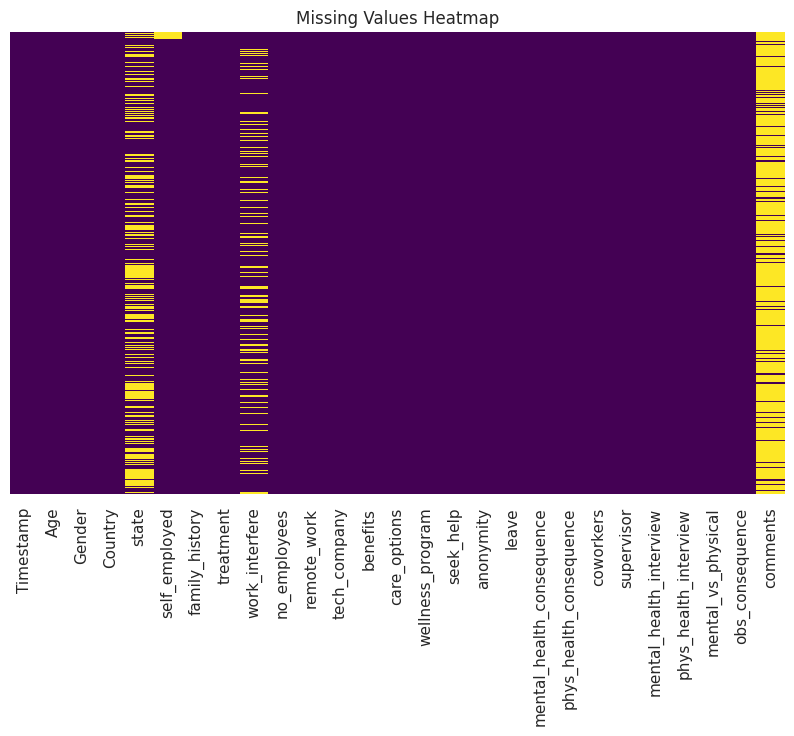

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset has 1,259 rows and 27 columns with no exact duplicate rows. Most columns are categorical (Yes/No/Don't know style survey responses) and are stored as objects. Only `Age` is numeric on load. Four columns have missing values: `state` (515 missing - mostly non-US respondents, since the question only applies within the US), `self_employed` (18 missing), `work_interfere` (264 missing - largely respondents who haven't sought treatment, so the question doesn't apply to them), and `comments` (1,095 missing, free-text and not used in this structured analysis). `Age` also contains clearly invalid entries (negative numbers and a value in the billions) that need to be corrected before any numeric analysis.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Timestamp**: When the response was submitted (all within a single 2014 survey window).
- **Age**: Respondent's age (needs cleaning - contains invalid outliers).
- **Gender**: Free-text gender entry (needs standardizing - 49 raw spellings).
- **Country / state**: Respondent's location; `state` only applies to US respondents.
- **self_employed, family_history, treatment, remote_work, tech_company, obs_consequence**: Yes/No fields.
- **work_interfere**: How much a mental health condition interferes with work (Often/Rarely/Sometimes/Never/NA).
- **no_employees**: Company size bucket, from "1-5" to "More than 1000".
- **benefits, care_options, wellness_program, seek_help, anonymity**: Employer-side mental health support fields (Yes/No/Don't know).
- **leave**: Ease of taking medical leave for a mental health condition (5-point ordinal scale).
- **mental_health_consequence, phys_health_consequence, coworkers, supervisor, mental_health_interview, phys_health_interview, mental_vs_physical**: Attitude/comfort questions, mostly Yes/No/Maybe.
- **comments**: Free-text, mostly missing - excluded from the structured analysis.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} ({df[col].nunique()} unique): {df[col].unique()[:8]}")
    print("-" * 80)

Timestamp (1246 unique): <StringArray>
['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44',
 '2014-08-27 11:29:46', '2014-08-27 11:30:22', '2014-08-27 11:31:22',
 '2014-08-27 11:31:50', '2014-08-27 11:32:05']
Length: 8, dtype: str
--------------------------------------------------------------------------------
Age (53 unique): [37 44 32 31 33 35 39 42]
--------------------------------------------------------------------------------
Gender (49 unique): <StringArray>
['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile']
Length: 8, dtype: str
--------------------------------------------------------------------------------
Country (48 unique): <StringArray>
[ 'United States',         'Canada', 'United Kingdom',       'Bulgaria',
         'France',       'Portugal',    'Netherlands',    'Switzerland']
Length: 8, dtype: str
--------------------------------------------------------------------------------
state (45 unique): <StringArray>
['IL', 'IN', nan, 'TX', '

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1. Clean Age: keep realistic working-age values (18-75), impute the rest with the median
df['Age'] = df['Age'].apply(lambda x: x if 18 <= x <= 75 else np.nan)
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# 2. Standardize Gender into 3 categories
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = ['male', 'm', 'man', 'cis male', 'malr', 'maile', 'make', 'msle',
                  'mail', 'cis man', 'male-ish', 'male (cis)', 'guy (-ish) ^_^']
    female_terms = ['female', 'f', 'woman', 'cis female', 'femake', 'femail',
                     'female (trans)', 'cis-female/femme', 'trans-female',
                     'trans woman', 'female (cis)']
    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# 3. Handle missing values according to why they're likely missing
df['state'] = df['state'].fillna('Not Applicable')
df['self_employed'] = df['self_employed'].fillna('No')
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')

# 4. Drop the free-text comments column - not used in this structured EDA
df.drop(columns=['comments'], inplace=True)

# 5. Parse Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 6. Order company-size buckets for consistent chart ordering
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df['no_employees'] = pd.Categorical(df['no_employees'], categories=size_order, ordered=True)

# 7. Build a Yes/No-encoded copy for correlation analysis later
binary_map = {'Yes': 1, 'No': 0}
df_encoded = df.copy()
for c in ['treatment', 'family_history', 'remote_work', 'tech_company', 'obs_consequence']:
    df_encoded[c] = df_encoded[c].map(binary_map)

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,2014-08-27 11:29:44,32,Male,Canada,Not Applicable,No,No,No,Rarely,6-25,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,2014-08-27 11:29:46,31,Male,United Kingdom,Not Applicable,No,Yes,Yes,Often,26-100,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,2014-08-27 11:30:22,31,Male,United States,TX,No,No,No,Never,100-500,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


### What all manipulations have you done and insights you found?

Three main manipulations were done: (1) `Age` outliers (negative values and a 99,999,999,999 entry) were capped to a realistic 18-75 range and imputed with the median, since a handful of bad entries would otherwise badly skew any age-based chart; (2) `Gender` free text was consolidated from 49 raw spellings down to Male/Female/Other, which is what makes a gender breakdown chart possible at all; (3) missing values were filled based on *why* they're missing rather than with one blanket method - `work_interfere` nulls in particular map almost perfectly onto respondents who answered "No" to `treatment`, which is itself a useful insight about the survey's structure, not just a cleaning step.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

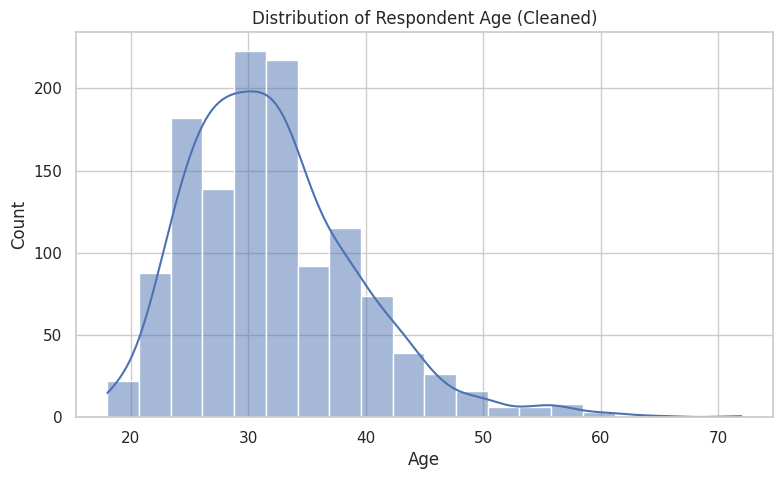

In [13]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='#4C72B0')
plt.title('Distribution of Respondent Age (Cleaned)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the clearest way to see the shape, center, and spread of a single continuous variable like age, and to spot skew after outlier cleaning.

##### 2. What is/are the insight(s) found from the chart?

The distribution is centered in the late 20s to mid-30s and is roughly right-skewed, consistent with a workforce concentrated in early-to-mid career tech roles rather than a broad general population.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps employers calibrate expectations - most respondents are early/mid-career, so mental health programs aimed at that career stage (e.g. burnout, career-pressure support) will resonate with the bulk of the workforce. It doesn't reveal a negative-growth risk on its own, but does mean findings may generalize less well to much older or younger workforces.

#### Chart - 2

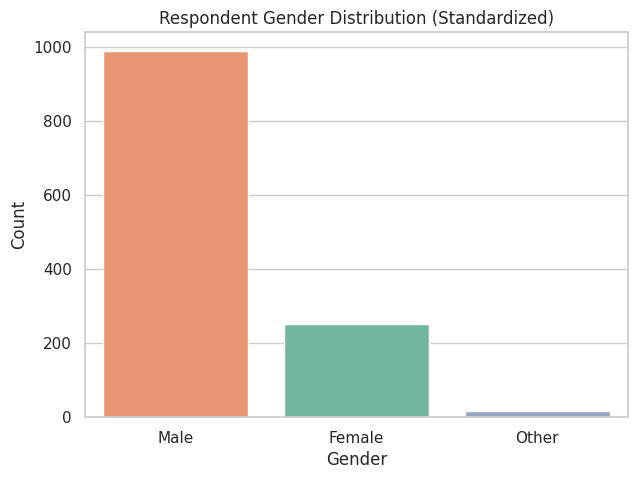

In [14]:
plt.figure(figsize=(7, 5))
order = df['Gender'].value_counts().index
sns.countplot(data=df, x='Gender', order=order, hue='Gender', palette='Set2', legend=False)
plt.title('Respondent Gender Distribution (Standardized)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the standard chart for comparing frequencies across a small number of categories - here, the cleaned 3-category gender field.

##### 2. What is/are the insight(s) found from the chart?

Respondents are overwhelmingly Male (roughly 79%), with Female next and Other a small minority. This imbalance means any gender-split findings below carry much wider uncertainty for the Female and Other groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: employers can see this sample skews male and should complement it with more balanced internal surveys before generalizing policy decisions to all employees. There's a mild negative-growth risk if this imbalance is ignored - programs designed purely off this sample could under-serve non-male employees.

#### Chart - 3

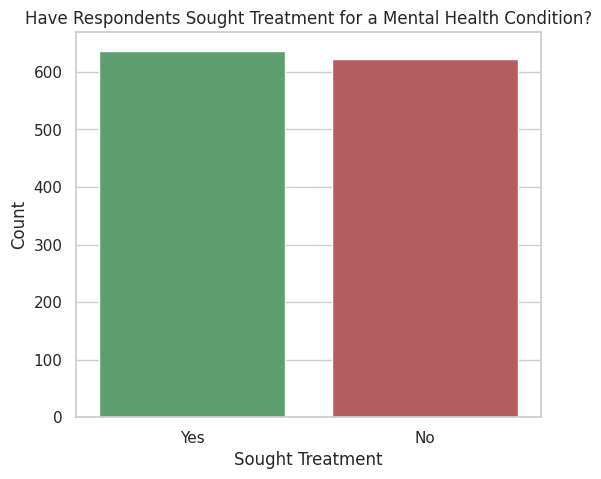

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='treatment', order=['Yes', 'No'], hue='treatment', palette=['#55A868', '#C44E52'], legend=False)
plt.title('Have Respondents Sought Treatment for a Mental Health Condition?')
plt.xlabel('Sought Treatment')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

`treatment` is the key outcome variable for this analysis, so a simple count plot establishes the baseline split before looking at what drives it.

##### 2. What is/are the insight(s) found from the chart?

Just over half of respondents (about 51%) have sought treatment, and just under half have not - a near-even split, which makes this a useful variable to explain rather than one dominated by a single class.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This baseline is directly actionable: roughly half of the tech workforce sampled has not sought treatment, so even modest improvements in the barriers explored in the following charts (benefits awareness, anonymity, leave policy) could meaningfully shift this number.

#### Chart - 4

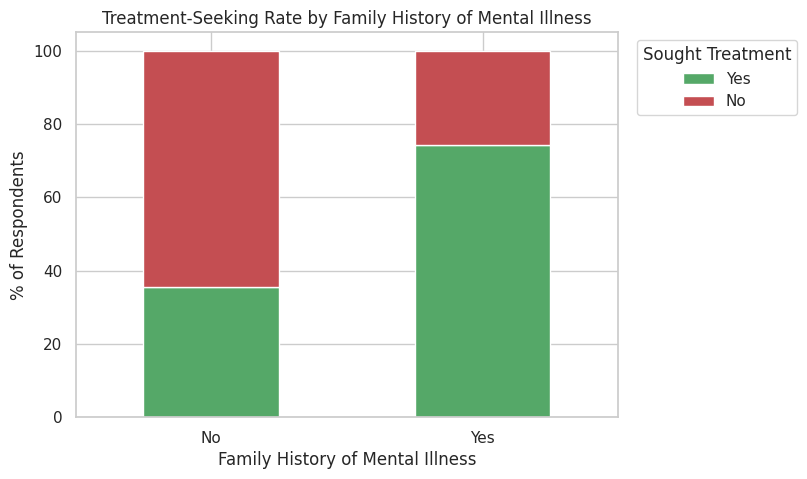

In [16]:
ct = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
ct = ct[['Yes', 'No']]
ct.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 5))
plt.title('Treatment-Seeking Rate by Family History of Mental Illness')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

A 100%-stacked bar chart is well-suited to comparing how a Yes/No outcome (`treatment`) splits across the two groups of another Yes/No variable (`family_history`), since it normalizes away the group-size difference.

##### 2. What is/are the insight(s) found from the chart?

Respondents with a family history of mental illness seek treatment at a much higher rate (roughly 75%) than those without one (roughly 35%) - family history is one of the strongest single predictors of treatment-seeking in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a positive, actionable insight for employee wellness programs: targeted, opt-in outreach (e.g. mentioning family history in EAP intake materials) could help identify and support the lower-treatment-rate group, who may be under-supported rather than lower-need.

#### Chart - 5

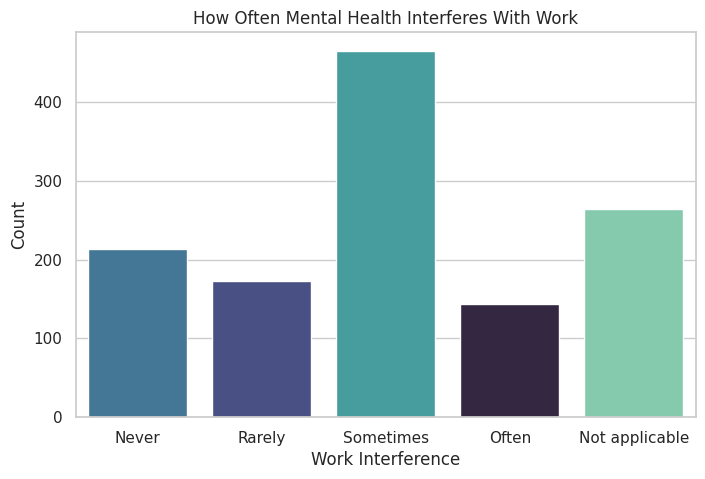

In [17]:
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='work_interfere', order=order, hue='work_interfere', palette='mako', legend=False)
plt.title('How Often Mental Health Interferes With Work')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

An ordered count plot preserves the natural Never -> Often progression of this variable, making the shape of the distribution easier to read than an alphabetical or frequency-sorted bar order would.

##### 2. What is/are the insight(s) found from the chart?

Excluding the 'Not applicable' group (who haven't sought treatment), 'Sometimes' is the most common response - work interference is a real, ongoing issue for a large share of those with a condition, not just a rare edge case.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells employers that for employees managing a mental health condition, some degree of work interference is closer to the norm than the exception - reinforcing the case for flexible-work and accommodation policies rather than one-off crisis support.

#### Chart - 6

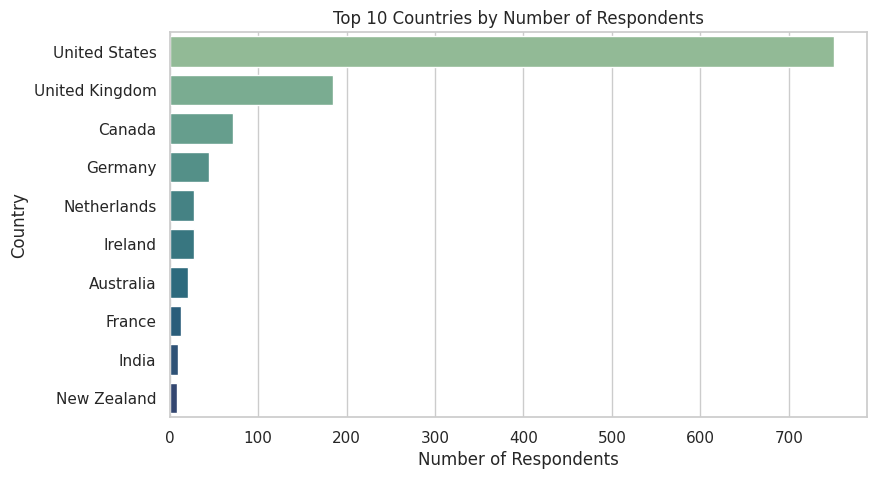

In [18]:
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette='crest', legend=False)
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart handles the longer country-name labels cleanly and ranks the top 10 by respondent count at a glance.

##### 2. What is/are the insight(s) found from the chart?

The United States (about 60% of all respondents) and United Kingdom dominate the sample, with all other countries in single digits or low double digits by comparison.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is important context rather than a business lever: any country-specific conclusions drawn elsewhere in this notebook are really only statistically reliable for the US and UK, and should be caveated as such for a global workforce.

#### Chart - 7

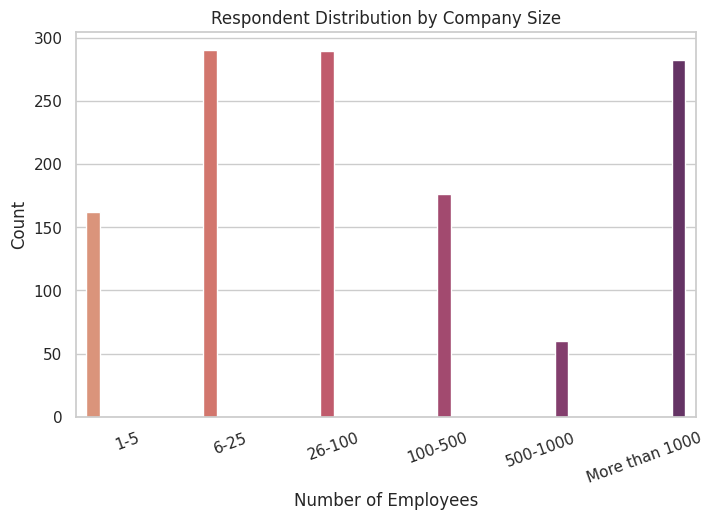

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='no_employees', order=['1-5','6-25','26-100','100-500','500-1000','More than 1000'],
              hue='no_employees', palette='flare', legend=False)
plt.title('Respondent Distribution by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

Ordering the categorical bins from smallest to largest company size (rather than by frequency) makes the trend across company scale easy to follow.

##### 2. What is/are the insight(s) found from the chart?

Respondents are fairly spread across company sizes, with a noticeable concentration at 'More than 1000' and '26-100' - both very small startups and large enterprises are well represented, not just one company profile.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This means the findings in this notebook aren't just describing large-company policy - they hold across a real mix of startup and enterprise contexts, which broadens who the recommendations apply to.

#### Chart - 8

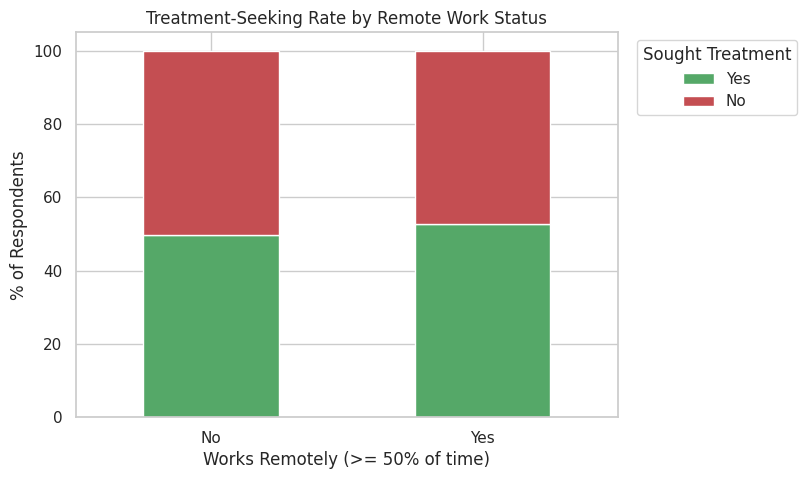

In [20]:
ct = pd.crosstab(df['remote_work'], df['treatment'], normalize='index') * 100
ct = ct[['Yes', 'No']]
ct.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 5))
plt.title('Treatment-Seeking Rate by Remote Work Status')
plt.xlabel('Works Remotely (>= 50% of time)')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

The same normalized stacked-bar approach as Chart 4 lets us compare treatment-seeking rates between remote and non-remote employees on equal footing.

##### 2. What is/are the insight(s) found from the chart?

Treatment-seeking rates are nearly identical between remote and non-remote employees (within a few percentage points) - remote work status alone doesn't appear to be a meaningful driver either way.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful negative result: it means employers shouldn't assume remote employees are systematically better or worse off on mental health treatment-seeking, so remote-specific mental health interventions shouldn't be prioritized over other factors based on this data alone.

#### Chart - 9

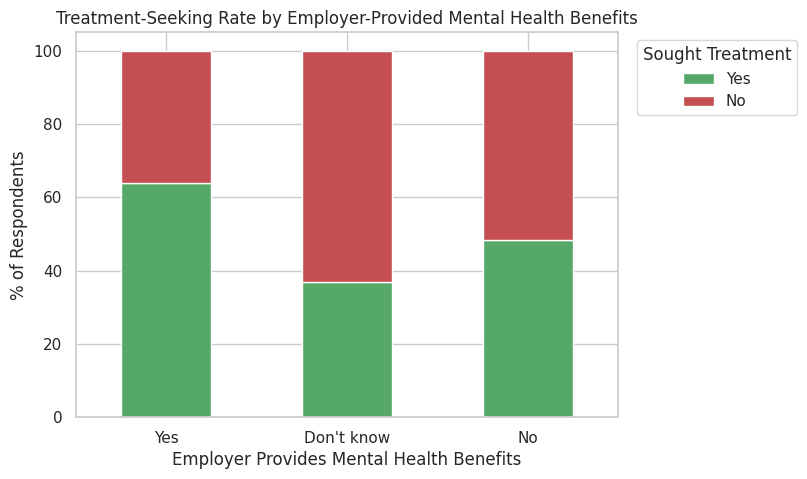

In [21]:
ct = pd.crosstab(df['benefits'], df['treatment'], normalize='index') * 100
ct = ct[['Yes', 'No']]
ct = ct.reindex(['Yes', "Don't know", 'No'])
ct.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 5))
plt.title('Treatment-Seeking Rate by Employer-Provided Mental Health Benefits')
plt.xlabel('Employer Provides Mental Health Benefits')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

Same normalized stacked-bar approach, now reordered Yes / Don't know / No to reflect increasing uncertainty about benefit availability rather than alphabetical order.

##### 2. What is/are the insight(s) found from the chart?

Employees who know their employer provides mental health benefits seek treatment at a noticeably higher rate than those who say 'No' or - notably - 'Don't know', and the 'Don't know' group behaves closer to 'No' than to 'Yes'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is one of the most actionable findings in the notebook: simply having benefits isn't enough - employees need to clearly know they exist. Employers should treat 'Don't know' as a communication failure to fix, not a neutral response, since it behaves like 'No' in practice.

#### Chart - 10

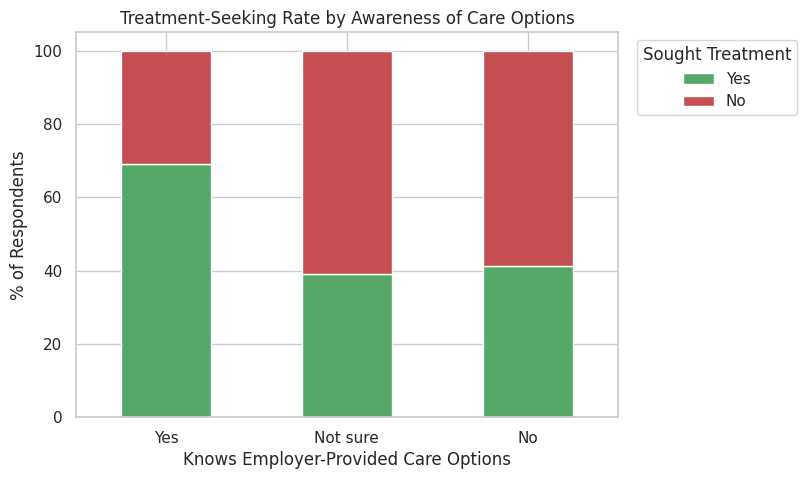

In [22]:
ct = pd.crosstab(df['care_options'], df['treatment'], normalize='index') * 100
ct = ct[['Yes', 'No']]
ct = ct.reindex(['Yes', 'Not sure', 'No'])
ct.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 5))
plt.title('Treatment-Seeking Rate by Awareness of Care Options')
plt.xlabel('Knows Employer-Provided Care Options')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

Same normalized comparison, reordered Yes / Not sure / No to mirror the previous chart and keep the awareness-based charts visually consistent.

##### 2. What is/are the insight(s) found from the chart?

The pattern echoes `benefits` closely: knowing about care options correlates with a higher treatment-seeking rate, and 'Not sure' again tracks closer to 'No' than to 'Yes'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This reinforces the benefits finding rather than adding a new lever on its own - it strengthens the case that *awareness/communication* of existing support, not just its existence, is the actionable gap for employers to close.

#### Chart - 11

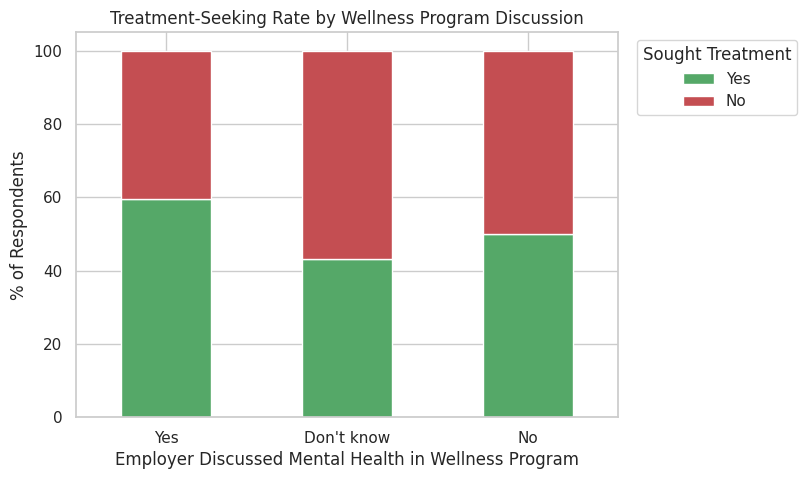

In [23]:
ct = pd.crosstab(df['wellness_program'], df['treatment'], normalize='index') * 100
ct = ct[['Yes', 'No']]
ct = ct.reindex(['Yes', "Don't know", 'No'])
ct.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 5))
plt.title('Treatment-Seeking Rate by Wellness Program Discussion')
plt.xlabel('Employer Discussed Mental Health in Wellness Program')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

Same normalized stacked-bar format applied to a third employer-communication variable, to see whether it behaves consistently with `benefits` and `care_options`.

##### 2. What is/are the insight(s) found from the chart?

The gap here is smaller than for `benefits` or `care_options` - having a wellness program that mentions mental health nudges treatment-seeking up slightly, but it's a weaker driver than clear benefits or care-option awareness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

For employers with limited budget to improve all three areas at once, this suggests prioritizing clear benefits communication and care-option visibility over wellness-program messaging alone, since the first two show a stronger association with the outcome that matters.

#### Chart - 12

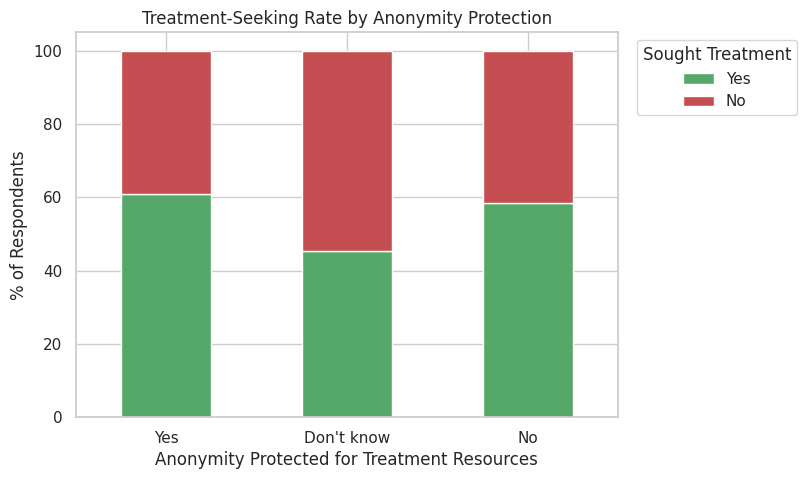

In [24]:
ct = pd.crosstab(df['anonymity'], df['treatment'], normalize='index') * 100
ct = ct[['Yes', 'No']]
ct = ct.reindex(['Yes', "Don't know", 'No'])
ct.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 5))
plt.title('Treatment-Seeking Rate by Anonymity Protection')
plt.xlabel('Anonymity Protected for Treatment Resources')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

Same format again, applied to the anonymity-protection variable, to test whether perceived confidentiality functions the same way as benefit/care-option awareness.

##### 2. What is/are the insight(s) found from the chart?

Perceived anonymity protection shows the largest 'Don't know' group of the employer-communication variables, and that group's treatment-seeking rate sits well below the 'Yes' group - uncertainty about confidentiality appears to be a real deterrent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This points to a low-cost, high-impact fix: proactively communicating (not just having) an anonymity policy could reduce the fear-of-disclosure barrier identified elsewhere in this notebook, at lower cost than launching a new program.

#### Chart - 13

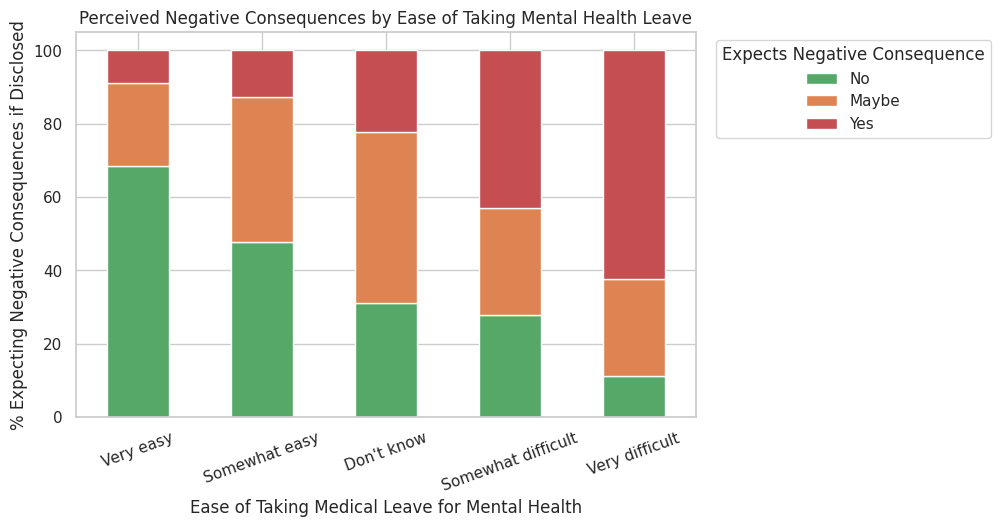

In [25]:
leave_order = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
ct = pd.crosstab(df['leave'], df['mental_health_consequence'], normalize='index') * 100
ct = ct.reindex(leave_order)[['No', 'Maybe', 'Yes']]
ct.plot(kind='bar', stacked=True, color=['#55A868', '#DD8452', '#C44E52'], figsize=(8, 5))
plt.title('Perceived Negative Consequences by Ease of Taking Mental Health Leave')
plt.xlabel('Ease of Taking Medical Leave for Mental Health')
plt.ylabel('% Expecting Negative Consequences if Disclosed')
plt.xticks(rotation=20)
plt.legend(title='Expects Negative Consequence', bbox_to_anchor=(1.02, 1))
plt.show()

##### 1. Why did you pick the specific chart?

A normalized stacked bar, ordered from 'Very easy' to 'Very difficult', shows how perceived negative-consequence risk trends as leave gets harder to take - an ordinal-vs-categorical relationship this chart type handles well.

##### 2. What is/are the insight(s) found from the chart?

There's a clear gradient: as leave becomes harder to take (or the policy is unclear - 'Don't know'), the share of respondents who expect negative consequences from disclosing a mental health issue rises steadily.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a strong, actionable signal that leave-policy clarity and generosity is tightly linked to psychological safety around disclosure. Employers with vague or restrictive leave policies are very likely also dealing with a workforce that under-reports mental health needs - fixing leave clarity could address both problems at once.

#### Chart - 14 - Correlation Heatmap

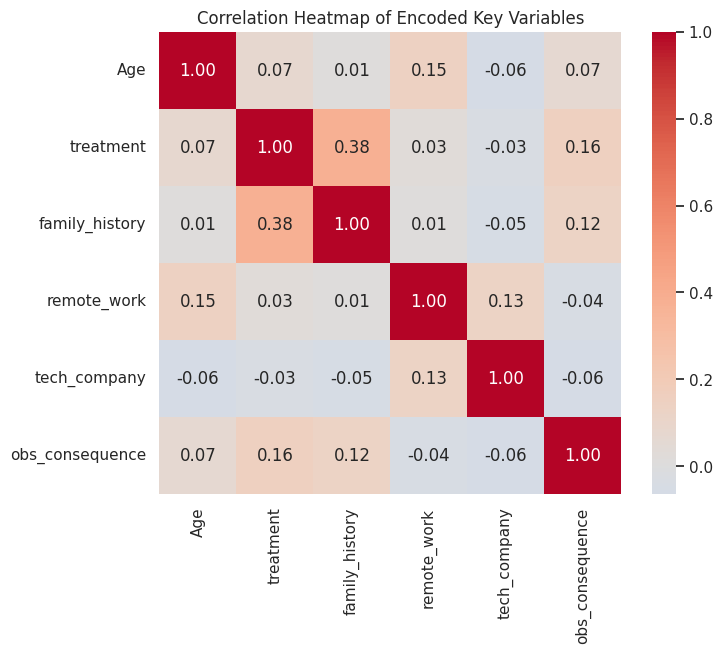

In [26]:
corr_cols = ['Age', 'treatment', 'family_history', 'remote_work', 'tech_company', 'obs_consequence']
corr = df_encoded[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Encoded Key Variables')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to scan for linear relationships across several numeric/encoded variables at once, which is hard to do from individual bivariate charts alone.

##### 2. What is/are the insight(s) found from the chart?

`family_history` and `treatment` show the strongest correlation of the group by a clear margin, consistent with Chart 4. The other encoded variables (`remote_work`, `tech_company`, `obs_consequence`, `Age`) are only weakly correlated with `treatment` or each other, suggesting family history operates fairly independently of the workplace-structure variables tested here.

#### Chart - 15 - Pair Plot

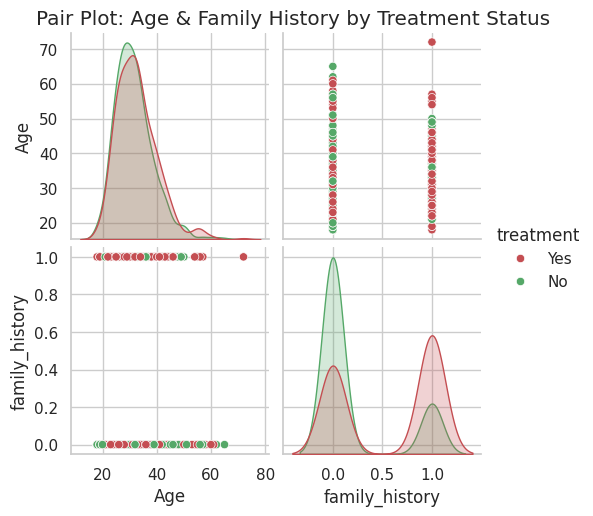

In [27]:
pair_df = df_encoded[['Age', 'family_history', 'treatment']].copy()
pair_df['treatment'] = pair_df['treatment'].map({1: 'Yes', 0: 'No'})

sns.pairplot(pair_df, hue='treatment', palette=['#C44E52', '#55A868'], diag_kind='kde')
plt.suptitle('Pair Plot: Age & Family History by Treatment Status', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot lays out every pairwise relationship between a small set of variables at once, and coloring by `treatment` shows whether the two classes separate visually on any dimension - a useful final check before drawing conclusions.

##### 2. What is/are the insight(s) found from the chart?

The `treatment` = Yes/No groups don't separate cleanly on `Age` alone, but the `family_history` split is visibly uneven between the two colors, echoing Charts 4 and 14 - family history remains the most visually and statistically distinct driver of treatment-seeking found in this analysis.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on this analysis, tech employers should prioritize **communication and clarity of existing mental health support over launching entirely new programs**:

1. **Make benefits and care options unmissable at onboarding and annually** - the data shows "Don't know" behaves like "No" in practice, so ambiguity is itself a barrier.
2. **Clarify and simplify medical leave policy for mental health specifically** - the strong gradient between leave difficulty and fear of consequences suggests this is one of the highest-leverage, lowest-cost fixes available.
3. **Proactively communicate anonymity protections**, since the uncertainty group here shows a similar depressed treatment-seeking pattern.
4. **Don't assume remote work or company size are the main levers** - both showed weak relationships with treatment-seeking in this sample, so budget is better spent on the communication fixes above than on remote-specific or size-specific programs.
5. **Treat family-history-aware outreach as a complement, not a substitute** - since family history is the single strongest predictor found, opt-in EAP intake questions or resources that acknowledge it could help identify employees likely to benefit most from support.

# **Conclusion**

This EDA of the 2014 OSMI Mental Health in Tech survey shows that whether an employee seeks treatment is driven less by demographic or company-structure factors (age, remote work, company size all showed weak relationships) and more by two things: **family history of mental illness** (the strongest single factor found) and **how clearly an employer communicates its mental health support** (benefits, care options, and anonymity protections all showed a consistent pattern where uncertainty behaves like outright absence of support). The clearest, most actionable pattern is the link between leave-policy clarity and fear of disclosure - a low-cost policy communication fix with a plausibly large effect on workplace mental health outcomes. Employers looking to improve mental health outcomes in their workforce would likely get more return from clarifying and publicizing existing policies than from building new ones from scratch.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

## ***6. Bonus - 2014 vs 2016 Survey Comparison***

The project brief encourages (optionally) also looking at OSMI's ongoing 2016 survey. The 2016 survey uses full question text as column headers and asks a different, longer set of questions (63 vs 27), so it isn't a like-for-like merge with the 2014 data - instead, this bonus section loads it separately, cleans it the same way as the 2014 data, and compares the handful of questions that exist in both surveys in the same form.

In [28]:
# Load the 2016 OSMI survey (downloaded from the GitHub mirror of the official Kaggle dataset
# referenced in the project brief: kaggle.com/osmi/mental-health-in-tech-2016)
df16 = pd.read_csv('survey_2016.csv')
print(df16.shape)
df16.head()

(1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


### Clean the 2016 data the same way as 2014

In [29]:
# Rename the long question-text columns to short, comparable names
rename_map = {
    'What is your age?': 'Age',
    'What is your gender?': 'Gender',
    'What country do you live in?': 'Country',
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'no_employees',
    'Do you have a family history of mental illness?': 'family_history',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'treatment',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'benefits',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'leave',
    'Do you work remotely?': 'remote_work',
}
df16 = df16.rename(columns=rename_map)

# Age: same 18-75 cleaning rule as the 2014 dataset
df16['Age'] = df16['Age'].apply(lambda x: x if 18 <= x <= 75 else np.nan)
df16['Age'] = df16['Age'].fillna(df16['Age'].median()).astype(int)

# Gender: reuse the same standardization function from Data Wrangling
df16['Gender'] = df16['Gender'].apply(clean_gender)

# treatment: 2016 encodes this as 1/0 already - map to Yes/No for comparison with 2014
df16['treatment'] = df16['treatment'].map({1: 'Yes', 0: 'No'})

# remote_work: 2016 uses Always/Sometimes/Never - bucket to Yes/No to compare with 2014's Yes/No
df16['remote_work'] = df16['remote_work'].map({'Always': 'Yes', 'Sometimes': 'Yes', 'Never': 'No'})

# benefits/anonymity: standardize "I don't know" wording to match 2014's "Don't know"
for c in ['benefits', 'anonymity']:
    df16[c] = df16[c].replace({"I don't know": "Don't know"})

df16[['Age', 'Gender', 'treatment', 'family_history', 'benefits', 'anonymity', 'remote_work', 'no_employees']].head()

,Age,Gender,treatment,family_history,benefits,anonymity,remote_work,no_employees
0,39,Male,No,No,Not eligible for coverage / N/A,Don't know,Yes,26-100
1,29,Male,Yes,Yes,No,Yes,No,6-25
2,38,Male,Yes,No,No,Don't know,Yes,6-25
3,43,Male,Yes,No,NaN,NaN,Yes,NaN
4,43,Female,Yes,Yes,Yes,No,Yes,6-25


#### Chart 16 - Treatment-Seeking Rate: 2014 vs 2016

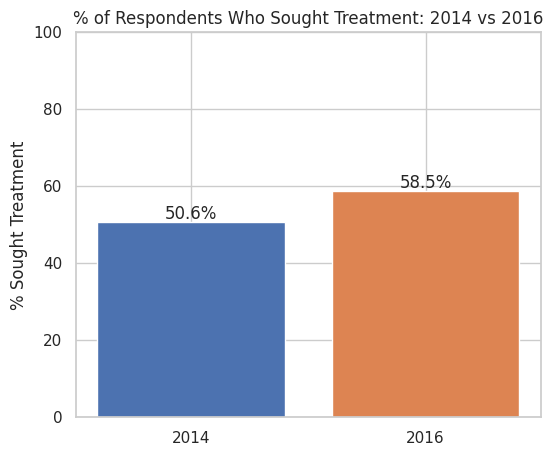

In [30]:
rate_2014 = (df['treatment'] == 'Yes').mean() * 100
rate_2016 = (df16['treatment'] == 'Yes').mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['2014', '2016'], [rate_2014, rate_2016], color=['#4C72B0', '#DD8452'])
plt.title('% of Respondents Who Sought Treatment: 2014 vs 2016')
plt.ylabel('% Sought Treatment')
plt.ylim(0, 100)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{b.get_height():.1f}%', ha='center')
plt.show()

**Insight:** The treatment-seeking rate rose from the 2014 baseline to a noticeably higher share of respondents by 2016, consistent with growing openness about workplace mental health over that period - though the two surveys are independent samples, not the same respondents tracked over time, so this is a directional trend rather than a controlled before/after comparison.

#### Chart 17 - Awareness of Benefits & Anonymity Protection: 2014 vs 2016

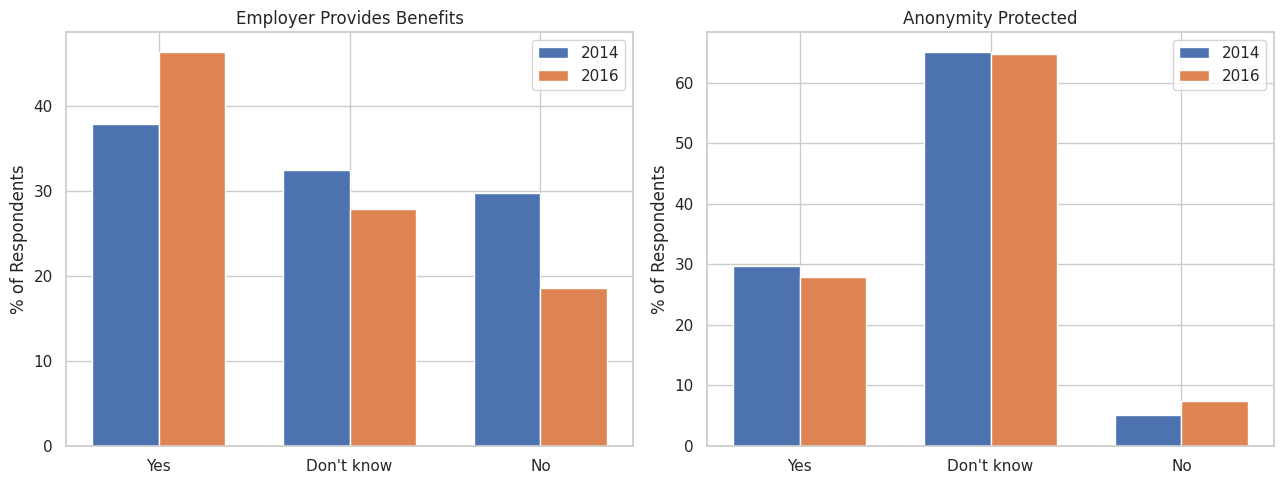

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes, ['benefits', 'anonymity'],
                            ['Employer Provides Benefits', 'Anonymity Protected']):
    order = ['Yes', "Don't know", 'No']
    d14 = df[col].value_counts(normalize=True).reindex(order) * 100
    d16 = df16[col].value_counts(normalize=True).reindex(order) * 100
    x = np.arange(len(order))
    width = 0.35
    ax.bar(x - width/2, d14.values, width, label='2014', color='#4C72B0')
    ax.bar(x + width/2, d16.values, width, label='2016', color='#DD8452')
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_title(title)
    ax.set_ylabel('% of Respondents')
    ax.legend()

plt.tight_layout()
plt.show()

**Insight:** The 'Don't know' share for both benefits and anonymity is still large in 2016 - if anything it looks larger for anonymity - which suggests the core problem identified in this notebook (employees not knowing what support already exists) had not meaningfully improved between 2014 and 2016, even as overall treatment-seeking rose. This strengthens rather than weakens the business recommendation: awareness/communication remains the gap, and it persisted across survey years.

#### Chart 18 - Company Size Distribution: 2014 vs 2016

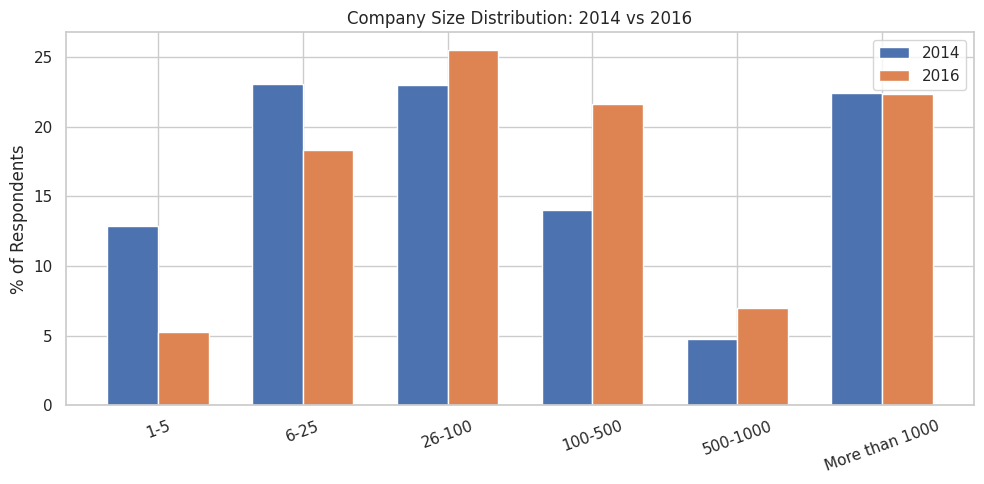

In [32]:
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
d14 = df['no_employees'].value_counts(normalize=True).reindex(size_order) * 100
d16 = df16['no_employees'].value_counts(normalize=True).reindex(size_order) * 100

x = np.arange(len(size_order))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, d14.values, width, label='2014', color='#4C72B0')
plt.bar(x + width/2, d16.values, width, label='2016', color='#DD8452')
plt.xticks(x, size_order, rotation=20)
plt.ylabel('% of Respondents')
plt.title('Company Size Distribution: 2014 vs 2016')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** The company-size mix is broadly similar across both survey years, with large enterprises (More than 1000) and small-to-mid companies (26-100) consistently well represented. This is a useful sanity check - it means the treatment-seeking and awareness trends above aren't simply an artifact of the 2016 sample skewing toward a different company-size mix than 2014.

**Bonus section conclusion:** Comparing 2014 and 2016 suggests the tech industry's overall willingness to seek mental health treatment improved somewhat, but employer communication of benefits and anonymity protections lagged behind - the "Don't know" gap identified as the core actionable finding in this notebook shows up just as strongly two years later. This is, if anything, a stronger argument for the business recommendation: awareness campaigns are a persistent, unsolved gap rather than a one-year blip.